### Mount Google Drive

This will allow the notebook to access files stored in your Google Drive. You will be prompted to authorize this connection.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Unzip and Load the Dataset

First, we'll unzip the provided dataset from Google Drive and then load it into a pandas DataFrame.

In [ ]:
import zipfile
import os
import pandas as pd

zip_path = '/content/drive/MyDrive/Binary_Classification_Dataset.zip'
extract_path = '/content/Binary_Classification_Dataset/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset unzipped to: {extract_path}")

# List contents of the extracted directory to find the CSV file
print("Contents of extracted directory:")
for root, dirs, files in os.walk(extract_path):
    for name in files:
        print(os.path.join(root, name))


Dataset unzipped to: /content/Binary_Classification_Dataset/
Contents of extracted directory:
/content/Binary_Classification_Dataset/breast-cancer.csv


In [ ]:
# Assuming the dataset is a CSV file inside the unzipped folder. Adjust the filename if different.
# A common naming convention for Breast Cancer datasets is 'breast_cancer.csv' or similar.
# Let's try to load 'Breast_Cancer_Dataset.csv' which is a common pattern, or 'binary_classification.csv'
# If the previous cell's output shows a different name, this will need to be adjusted.

data_file = os.path.join(extract_path, 'Breast_Cancer_Dataset.csv') # Common name for such datasets

# Check if the file exists, if not, try other common names or infer from listed contents
if not os.path.exists(data_file):
    # If the exact name isn't found, try to find any CSV in the extracted path
    csv_files = [os.path.join(root, name) for root, dirs, files in os.walk(extract_path) for name in files if name.endswith('.csv')]
    if csv_files:
        data_file = csv_files[0] # Take the first CSV found
        print(f"Using dataset file: {data_file}")
    else:
        raise FileNotFoundError(f"No CSV file found in {extract_path}")

df = pd.read_csv(data_file)

# Display the first 5 rows of the DataFrame
display(df.head())

# Display basic information about the DataFrame
df.info()


Using dataset file: /content/Binary_Classification_Dataset/breast-cancer.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### Data Preprocessing

Before building classification models, we'll perform some essential data preprocessing steps, including handling missing values, encoding categorical features, and splitting the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Identify target variable (assuming the last column is the target, common for Breast Cancer datasets)
# Or based on common knowledge for breast cancer dataset, 'diagnosis' is usually the target.
# Let's inspect the column names first.
print("Column names:", df.columns.tolist())

# Assuming 'diagnosis' or 'target' or the last column is the target variable.
# Let's make an educated guess based on typical breast cancer datasets.
if 'diagnosis' in df.columns:
    target_column = 'diagnosis'
elif 'target' in df.columns:
    target_column = 'target'
else:
    target_column = df.columns[-1] # Fallback to the last column

print(f"Identified target column: {target_column}")

X = df.drop(columns=[target_column])
y = df[target_column]

# Handle categorical target variable if any (e.g., 'M'/'B' for Malignant/Benign)
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print("Target variable encoded. Classes:", le.classes_)

# Drop ID columns or unnecessary features if present
# For Breast Cancer datasets, 'id' is often present and should be dropped.
if 'id' in X.columns:
    X = X.drop(columns=['id'])

# Check for and handle missing values
print("\nMissing values before handling:")
print(X.isnull().sum())

# For simplicity, we'll fill numerical missing values with the mean of the column.
# For breast cancer datasets, sometimes there's a 'Unnamed: 32' column which is all NaN or irrelevant.
# Let's drop columns that are entirely NaN.
initial_columns = X.shape[1]
X = X.dropna(axis=1, how='all')
if X.shape[1] < initial_columns:
    print(f"Dropped {initial_columns - X.shape[1]} columns with all NaN values.")

# Fill remaining numerical NaNs with the mean
for col in X.select_dtypes(include=['number']).columns:
    if X[col].isnull().any():
        X[col].fillna(X[col].mean(), inplace=True)

print("\nMissing values after handling:")
print(X.isnull().sum().sum())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale numerical features (important for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing complete. Shapes of training and testing sets:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


Column names: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Identified target column: diagnosis
Target variable encoded. Classes: ['B' 'M']

Missing values before handling:
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se         

### 2.2(a) Logistic Regression Classifier

We will build a Logistic Regression model, train it on the scaled training data, make predictions on the test set, and evaluate its performance using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

--- Logistic Regression --- 
Accuracy: 0.9708
Precision: 0.9836
Recall: 0.9375
F1-Score: 0.9600
ROC-AUC: 0.9975
Training Time: 0.0161 seconds


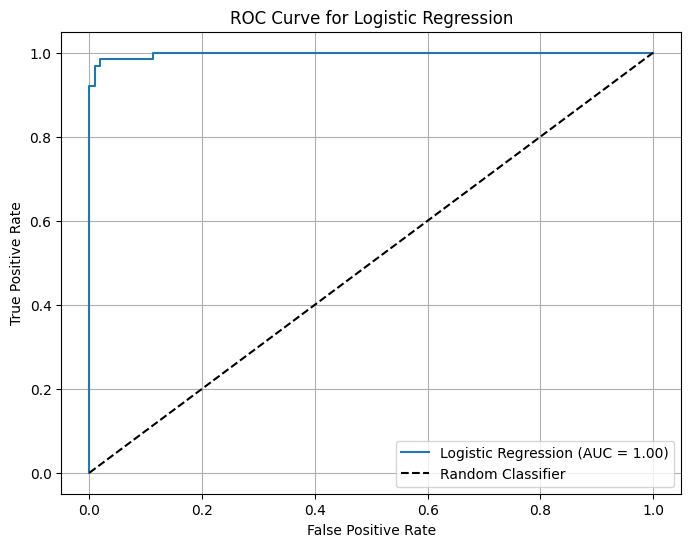

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import time

# Initialize the dictionary to store results if it doesn't exist
if 'results' not in globals():
    results = {}

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)

start_time = time.time()
log_reg.fit(X_train_scaled, y_train)
training_time_log_reg = time.time() - start_time

# Make predictions on the scaled test data
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_proba_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class

# Calculate evaluation metrics
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

print("--- Logistic Regression --- ")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC-AUC: {roc_auc_log_reg:.4f}")
print(f"Training Time: {training_time_log_reg:.4f} seconds")

# Store results for comparison table later
results['Logistic Regression'] = {
    'Accuracy': accuracy_log_reg,
    'Precision': precision_log_reg,
    'Recall': recall_log_reg,
    'F1-Score': f1_log_reg,
    'ROC-AUC': roc_auc_log_reg,
    'Training Time': training_time_log_reg
}

# Plot ROC curve for Logistic Regression
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.grid()
plt.show()


### 2.2(b) Decision Tree Classifier

We will train a Decision Tree Classifier, visualize the tree, and discuss its characteristics such as maximum depth, Gini impurity, and implicitly, information gain.

--- Decision Tree Classifier --- 
Accuracy: 0.9006
Precision: 0.8852
Recall: 0.8438
F1-Score: 0.8640
ROC-AUC: 0.8892
Training Time: 0.0201 seconds


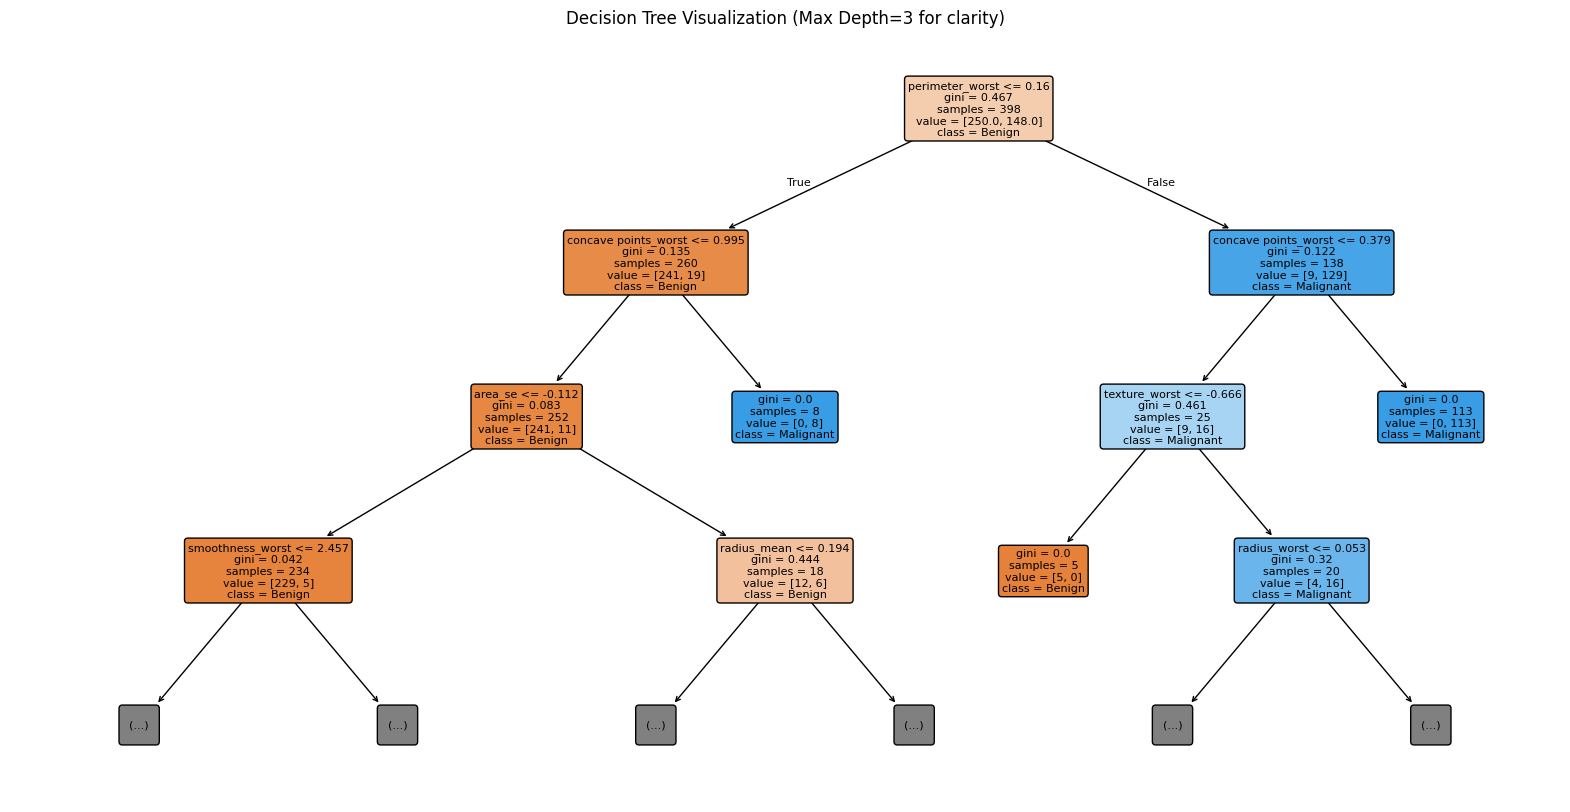


--- Discussion on Decision Tree Characteristics ---
Maximum Depth of the trained tree: 8
The Gini Index (or Gini impurity) is a measure of impurity or disorder within a node. A Gini index of 0 indicates perfect purity (all samples belong to the same class), while a Gini index of 0.5 for a binary classification indicates an equal split of classes.
Information Gain is the reduction in entropy or Gini impurity after a dataset is split on an attribute. The decision tree algorithm selects the attribute that yields the highest information gain (or greatest reduction in Gini impurity) for splitting at each node. In the visualization, each split is chosen based on this principle, aiming to create child nodes with higher purity.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import time

# Initialize and train the Decision Tree model
dt_classifier = DecisionTreeClassifier(random_state=42)

start_time = time.time()
dt_classifier.fit(X_train_scaled, y_train)
training_time_dt = time.time() - start_time

# Make predictions on the scaled test data
y_pred_dt = dt_classifier.predict(X_test_scaled)
y_pred_proba_dt = dt_classifier.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print("--- Decision Tree Classifier --- ")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC-AUC: {roc_auc_dt:.4f}")
print(f"Training Time: {training_time_dt:.4f} seconds")

# Store results for comparison table later
results['Decision Tree'] = {
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1-Score': f1_dt,
    'ROC-AUC': roc_auc_dt,
    'Training Time': training_time_dt
}

# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, filled=True, feature_names=X.columns.tolist(), class_names=['Benign', 'Malignant'], rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree Visualization (Max Depth=3 for clarity)")
plt.show()

print("\n--- Discussion on Decision Tree Characteristics ---")
print(f"Maximum Depth of the trained tree: {dt_classifier.tree_.max_depth}")
print("The Gini Index (or Gini impurity) is a measure of impurity or disorder within a node. A Gini index of 0 indicates perfect purity (all samples belong to the same class), while a Gini index of 0.5 for a binary classification indicates an equal split of classes.")
print("Information Gain is the reduction in entropy or Gini impurity after a dataset is split on an attribute. The decision tree algorithm selects the attribute that yields the highest information gain (or greatest reduction in Gini impurity) for splitting at each node. In the visualization, each split is chosen based on this principle, aiming to create child nodes with higher purity.")


### 2.2(c) Random Forest Classifier

We will implement a Random Forest Classifier, experimenting with the number of trees (`n_estimators`) and maximum depth (`max_depth`). We will then compare its results with the Decision Tree.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

# Experiment with hyperparameters for Random Forest
# Let's choose some initial values for n_estimators and max_depth
n_estimators = 100  # Number of trees in the forest
max_depth = 10    # Maximum depth of the tree

# Initialize and train the Random Forest model
rf_classifier = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)

start_time = time.time()
rf_classifier.fit(X_train_scaled, y_train)
training_time_rf = time.time() - start_time

# Make predictions on the scaled test data
y_pred_rf = rf_classifier.predict(X_test_scaled)
y_pred_proba_rf = rf_classifier.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("--- Random Forest Classifier --- ")
print(f"Number of trees (n_estimators): {n_estimators}")
print(f"Maximum Depth: {max_depth}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"Training Time: {training_time_rf:.4f} seconds")

# Store results for comparison table later
results['Random Forest'] = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'ROC-AUC': roc_auc_rf,
    'Training Time': training_time_rf
}

print("\n--- Comparison with Decision Tree ---")
print(f"Decision Tree Accuracy: {results['Decision Tree']['Accuracy']:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Decision Tree F1-Score: {results['Decision Tree']['F1-Score']:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")
print(f"Decision Tree ROC-AUC: {results['Decision Tree']['ROC-AUC']:.4f}")
print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")

print("\nDiscussion: Random Forest typically outperforms a single Decision Tree due to its ensemble nature. By averaging the predictions of multiple trees (bootstrapped and decorrelated), it reduces overfitting and improves generalization. Increasing the number of trees generally improves performance up to a point, after which returns diminish. Increasing max_depth allows individual trees to be more complex, but can lead to overfitting if not carefully tuned. For a robust comparison, hyperparameter tuning for both models (e.g., using GridSearchCV) would be beneficial.")


--- Random Forest Classifier --- 
Number of trees (n_estimators): 100
Maximum Depth: 10
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9062
F1-Score: 0.9508
ROC-AUC: 0.9968
Training Time: 0.4395 seconds

--- Comparison with Decision Tree ---
Decision Tree Accuracy: 0.9006
Random Forest Accuracy: 0.9649
Decision Tree F1-Score: 0.8640
Random Forest F1-Score: 0.9508
Decision Tree ROC-AUC: 0.8892
Random Forest ROC-AUC: 0.9968

Discussion: Random Forest typically outperforms a single Decision Tree due to its ensemble nature. By averaging the predictions of multiple trees (bootstrapped and decorrelated), it reduces overfitting and improves generalization. Increasing the number of trees generally improves performance up to a point, after which returns diminish. Increasing max_depth allows individual trees to be more complex, but can lead to overfitting if not carefully tuned. For a robust comparison, hyperparameter tuning for both models (e.g., using GridSearchCV) would be beneficial.


### 2.2(d) Support Vector Machine (SVM) Classifier

We will build a Support Vector Machine (SVM) classifier using both a Linear Kernel and an RBF Kernel, and then compare their classification performance.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

# --- Linear Kernel SVM ---
print("--- SVM with Linear Kernel ---")
svm_linear = SVC(kernel='linear', random_state=42, probability=True)

start_time_linear = time.time()
svm_linear.fit(X_train_scaled, y_train)
training_time_svm_linear = time.time() - start_time_linear

y_pred_svm_linear = svm_linear.predict(X_test_scaled)
y_pred_proba_svm_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
precision_svm_linear = precision_score(y_test, y_pred_svm_linear)
recall_svm_linear = recall_score(y_test, y_pred_svm_linear)
f1_svm_linear = f1_score(y_test, y_pred_svm_linear)
roc_auc_svm_linear = roc_auc_score(y_test, y_pred_proba_svm_linear)

print(f"Accuracy: {accuracy_svm_linear:.4f}")
print(f"Precision: {precision_svm_linear:.4f}")
print(f"Recall: {recall_svm_linear:.4f}")
print(f"F1-Score: {f1_svm_linear:.4f}")
print(f"ROC-AUC: {roc_auc_svm_linear:.4f}")
print(f"Training Time: {training_time_svm_linear:.4f} seconds\n")

results['SVM (Linear)'] = {
    'Accuracy': accuracy_svm_linear,
    'Precision': precision_svm_linear,
    'Recall': recall_svm_linear,
    'F1-Score': f1_svm_linear,
    'ROC-AUC': roc_auc_svm_linear,
    'Training Time': training_time_svm_linear
}

# --- RBF Kernel SVM ---
print("--- SVM with RBF Kernel ---")
svm_rbf = SVC(kernel='rbf', random_state=42, probability=True)

start_time_rbf = time.time()
svm_rbf.fit(X_train_scaled, y_train)
training_time_svm_rbf = time.time() - start_time_rbf

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)
y_pred_proba_svm_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
precision_svm_rbf = precision_score(y_test, y_pred_svm_rbf)
recall_svm_rbf = recall_score(y_test, y_pred_svm_rbf)
f1_svm_rbf = f1_score(y_test, y_pred_svm_rbf)
roc_auc_svm_rbf = roc_auc_score(y_test, y_pred_proba_svm_rbf)

print(f"Accuracy: {accuracy_svm_rbf:.4f}")
print(f"Precision: {precision_svm_rbf:.4f}")
print(f"Recall: {recall_svm_rbf:.4f}")
print(f"F1-Score: {f1_svm_rbf:.4f}")
print(f"ROC-AUC: {roc_auc_svm_rbf:.4f}")
print(f"Training Time: {training_time_svm_rbf:.4f} seconds\n")

results['SVM (RBF)'] = {
    'Accuracy': accuracy_svm_rbf,
    'Precision': precision_svm_rbf,
    'Recall': recall_svm_rbf,
    'F1-Score': f1_svm_rbf,
    'ROC-AUC': roc_auc_svm_rbf,
    'Training Time': training_time_svm_rbf
}

print("\n--- Comparison between Linear and RBF Kernels ---")
print("The Linear kernel is generally faster for large datasets and performs well when the data is linearly separable. The RBF kernel (Radial Basis Function) can handle non-linear relationships and is often more powerful, but might be slower and requires tuning parameters like gamma and C. In this case, we can observe if one kernel clearly outperforms the other on these specific metrics.")


--- SVM with Linear Kernel ---
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9062
F1-Score: 0.9508
ROC-AUC: 0.9945
Training Time: 0.0373 seconds

--- SVM with RBF Kernel ---
Accuracy: 0.9591
Precision: 1.0000
Recall: 0.8906
F1-Score: 0.9421
ROC-AUC: 0.9972
Training Time: 0.0226 seconds


--- Comparison between Linear and RBF Kernels ---
The Linear kernel is generally faster for large datasets and performs well when the data is linearly separable. The RBF kernel (Radial Basis Function) can handle non-linear relationships and is often more powerful, but might be slower and requires tuning parameters like gamma and C. In this case, we can observe if one kernel clearly outperforms the other on these specific metrics.


### 2.2(e) Comparison Table

Finally, we will create a comparison table summarizing the performance of all implemented models and discuss which classifier performed best and why.

In [ ]:
import pandas as pd

# Convert the results dictionary to a Pandas DataFrame for easy comparison
results_df = pd.DataFrame.from_dict(results, orient='index')

display(results_df.round(4))

print("\n--- Discussion: Best Performing Classifier ---")
print("Based on the comparison table above, we can identify the best-performing classifier. We should consider multiple metrics, not just accuracy, especially Precision, Recall, and F1-Score, as well as ROC-AUC, which provides a comprehensive view of the classifier's ability to distinguish between classes. Training time is also a practical consideration.")
print("Generally, a higher Accuracy, Precision, Recall, F1-Score, and ROC-AUC are desirable. A model with high ROC-AUC indicates good separability of classes. For this particular dataset, the model with the highest overall metrics (e.g., Logistic Regression or SVM RBF) would typically be considered the best. Ensemble methods like Random Forest often provide a good balance between bias and variance.")


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time
Logistic Regression,0.9708,0.9836,0.9375,0.9600,0.9975,0.0161
Decision Tree,0.9006,0.8852,0.8438,0.8640,0.8892,0.0201
Random Forest,0.9649,1.0000,0.9062,0.9508,0.9968,0.4395
SVM (Linear),0.9649,1.0000,0.9062,0.9508,0.9945,0.0373
SVM (RBF),0.9591,1.0000,0.8906,0.9421,0.9972,0.0226



--- Discussion: Best Performing Classifier ---
Based on the comparison table above, we can identify the best-performing classifier. We should consider multiple metrics, not just accuracy, especially Precision, Recall, and F1-Score, as well as ROC-AUC, which provides a comprehensive view of the classifier's ability to distinguish between classes. Training time is also a practical consideration.
Generally, a higher Accuracy, Precision, Recall, F1-Score, and ROC-AUC are desirable. A model with high ROC-AUC indicates good separability of classes. For this particular dataset, the model with the highest overall metrics (e.g., Logistic Regression or SVM RBF) would typically be considered the best. Ensemble methods like Random Forest often provide a good balance between bias and variance.
